# LOD, Blending, Joining in Google Sheet and Python
- Level of Detail (LOD) - at what level do you want to calculate the value
- https://docs.google.com/spreadsheets/d/19EqsXhG4RF8O1cb6hFDicyM2orrkcRO9z4VCvaPXwiU/edit?gid=1873060452#gid=1873060452

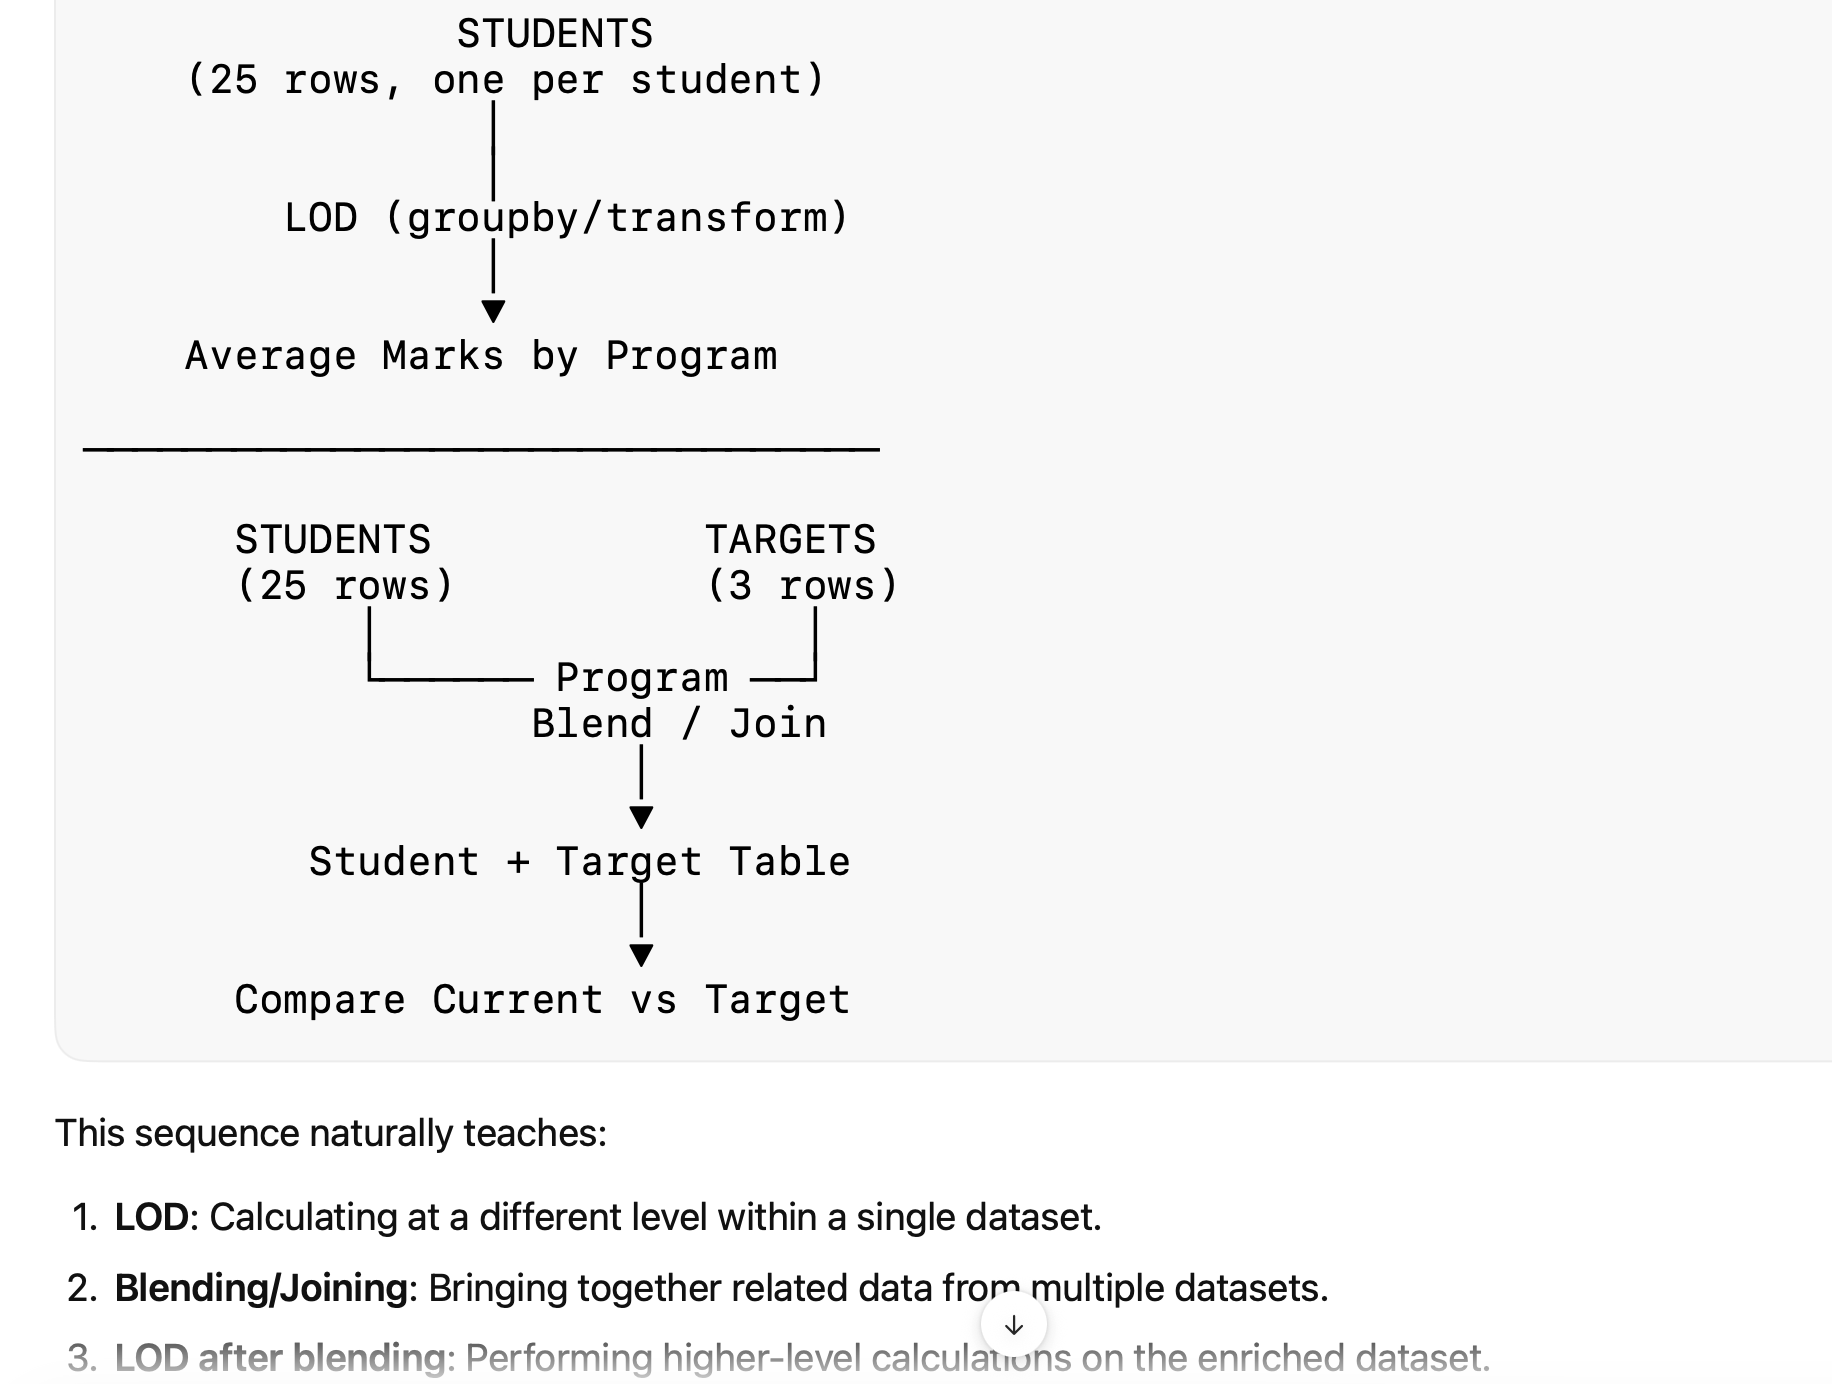

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pformat

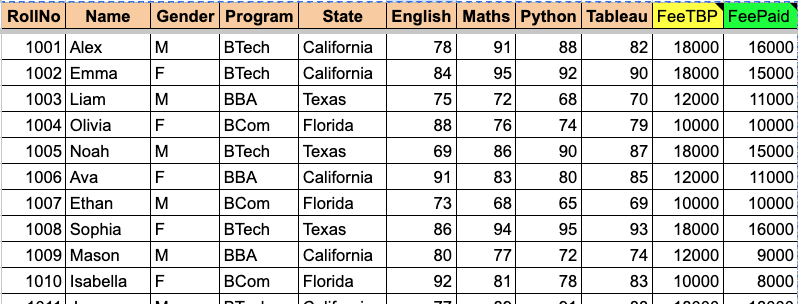

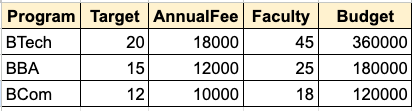

In [24]:
#copy data from clipboard
students = pd.read_clipboard(sep='\t')
students.shape

(25, 11)

In [25]:
students.head()

,RollNo,Name,Gender,Program,State,English,Maths,Python,Tableau,FeeTBP,FeePaid
0,1001,Alex,M,BTech,California,78,91,88,82,18000,14000
1,1002,Emma,F,BTech,California,84,95,92,90,18000,13000
2,1003,Liam,M,BBA,Texas,75,72,68,70,12000,10000
3,1004,Olivia,F,BCom,Florida,88,76,74,79,10000,9000
4,1005,Noah,M,BTech,Texas,69,86,90,87,18000,17000


In [6]:
# read data from script
sdata = students.to_dict(orient='list')
#print(sdata)

In [ ]:
sdata2 = pd.DataFrame(sdata)
sdata2.head()

In [30]:
students['TotalMarks'] = students['English'] + students['Maths'] + students['Python'] + students['Tableau']
students.head()

,RollNo,Name,Gender,Program,State,English,Maths,Python,Tableau,FeeTBP,FeePaid,avgPython,TotalMarks
0,1001,Alex,M,BTech,California,78,91,88,82,18000,14000,91.8,339
1,1002,Emma,F,BTech,California,84,95,92,90,18000,13000,91.8,361
2,1003,Liam,M,BBA,Texas,75,72,68,70,12000,10000,75.0,285
3,1004,Olivia,F,BCom,Florida,88,76,74,79,10000,9000,70.8,317
4,1005,Noah,M,BTech,Texas,69,86,90,87,18000,17000,91.8,332


In [14]:
#copy target data : goto sheet
targets = pd.read_clipboard(sep='\t')
targets.shape

(3, 5)

In [15]:
targets

,Program,Target,AnnualFee,Faculty,Budget
0,BTech,20,18000,45,360000
1,BBA,15,12000,25,180000
2,BCom,12,10000,18,120000


In [16]:
# create a script to create data from here
tdata = targets.to_dict(orient='list')
tdata

{'Program': ['BTech', 'BBA', 'BCom'],
 'Target': [20, 15, 12],
 'AnnualFee': [18000, 12000, 10000],
 'Faculty': [45, 25, 18],
 'Budget': [360000, 180000, 120000]}

In [26]:
targets2 = pd.DataFrame(tdata)
targets2

,Program,Target,AnnualFee,Faculty,Budget
0,BTech,20,18000,45,360000
1,BBA,15,12000,25,180000
2,BCom,12,10000,18,120000


In [27]:
## LOD : {FIXED [Program] : AVG([Python]) }
lod1 = students.groupby('Program').agg({'Python':'mean'}).reset_index().round(1)
lod1

,Program,Python
0,BBA,75.0
1,BCom,70.8
2,BTech,91.8


In [31]:
students['avgPython'] = students.groupby('Program')['Python'].transform('mean').round(1)
students.head()
#show avgPython marks against each student depending upon on its program name

,RollNo,Name,Gender,Program,State,English,Maths,Python,Tableau,FeeTBP,FeePaid,avgPython,TotalMarks
0,1001,Alex,M,BTech,California,78,91,88,82,18000,14000,91.8,339
1,1002,Emma,F,BTech,California,84,95,92,90,18000,13000,91.8,361
2,1003,Liam,M,BBA,Texas,75,72,68,70,12000,10000,75.0,285
3,1004,Olivia,F,BCom,Florida,88,76,74,79,10000,9000,70.8,317
4,1005,Noah,M,BTech,Texas,69,86,90,87,18000,17000,91.8,332


In [32]:
## LOD : {FIXED [Program] : AVG([TotalMarks]) }
lod2 = students.groupby('Program').agg({'TotalMarks':'mean'}).reset_index().round(1)
lod2

,Program,TotalMarks
0,BBA,315.6
1,BCom,299.8
2,BTech,353.1


In [33]:
# Difference of Total Marks against Average Marks of class depending upon the program
students['progAvg'] = students.groupby('Program')['TotalMarks'].transform('mean').round(1)
students.head()

,RollNo,Name,Gender,Program,State,English,Maths,Python,Tableau,FeeTBP,FeePaid,avgPython,TotalMarks,progAvg
0,1001,Alex,M,BTech,California,78,91,88,82,18000,14000,91.8,339,353.1
1,1002,Emma,F,BTech,California,84,95,92,90,18000,13000,91.8,361,353.1
2,1003,Liam,M,BBA,Texas,75,72,68,70,12000,10000,75.0,285,315.6
3,1004,Olivia,F,BCom,Florida,88,76,74,79,10000,9000,70.8,317,299.8
4,1005,Noah,M,BTech,Texas,69,86,90,87,18000,17000,91.8,332,353.1


In [34]:
students["Diff_Total_progAvg"] = ( students["TotalMarks"] - students["progAvg"])
students.head()

,RollNo,Name,Gender,Program,State,English,Maths,Python,Tableau,FeeTBP,FeePaid,avgPython,TotalMarks,progAvg,Diff_Total_progAvg
0,1001,Alex,M,BTech,California,78,91,88,82,18000,14000,91.8,339,353.1,-14.1
1,1002,Emma,F,BTech,California,84,95,92,90,18000,13000,91.8,361,353.1,7.9
2,1003,Liam,M,BBA,Texas,75,72,68,70,12000,10000,75.0,285,315.6,-30.6
3,1004,Olivia,F,BCom,Florida,88,76,74,79,10000,9000,70.8,317,299.8,17.2
4,1005,Noah,M,BTech,Texas,69,86,90,87,18000,17000,91.8,332,353.1,-21.1


## Blending
- Joining at different Aggregate Levels
- Group1 
    - Program : Students Admitted, Fee Collected
- Group2
    - Program : Admissions Target, Budget 

In [35]:
students.groupby('Program').agg({'RollNo':'count', 'FeePaid':'sum'}).round(0).reset_index()

,Program,RollNo,FeePaid
0,BBA,8,83000
1,BCom,8,68000
2,BTech,9,141000


In [36]:
students.groupby('Program').agg(Admissions = ('RollNo', 'count'), FeeCollected = ('FeePaid','sum')).round(0).reset_index()
#best way

,Program,Admissions,FeeCollected
0,BBA,8,83000
1,BCom,8,68000
2,BTech,9,141000


In [37]:
#Expressions Way
aggrExpr = {'Admissions' : ('RollNo', 'count'), 'FeeCollected' :('FeePaid','sum')}
students.groupby('Program').agg(**aggrExpr).round(1).reset_index()

,Program,Admissions,FeeCollected
0,BBA,8,83000
1,BCom,8,68000
2,BTech,9,141000


In [38]:
# Group1
blend1 = students.groupby('Program').agg(Admissions = ('RollNo', 'count'), FeeCollected = ('FeePaid','sum')).round(0).reset_index()
blend1

,Program,Admissions,FeeCollected
0,BBA,8,83000
1,BCom,8,68000
2,BTech,9,141000


In [39]:
blend2 = targets.copy()
blend2

,Program,Target,AnnualFee,Faculty,Budget
0,BTech,20,18000,45,360000
1,BBA,15,12000,25,180000
2,BCom,12,10000,18,120000


In [40]:
blending = pd.merge(blend1, blend2, on='Program')
blending

,Program,Admissions,FeeCollected,Target,AnnualFee,Faculty,Budget
0,BBA,8,83000,15,12000,25,180000
1,BCom,8,68000,12,10000,18,120000
2,BTech,9,141000,20,18000,45,360000


In [41]:
# Pipeline style adding columns
blending.assign(admAch = lambda x: round(100 * x['Admissions'] / x['Target']), 
                budgetAch = lambda x : round(100 * x['FeeCollected']/x['Budget']))

,Program,Admissions,FeeCollected,Target,AnnualFee,Faculty,Budget,admAch,budgetAch
0,BBA,8,83000,15,12000,25,180000,53.0,46.0
1,BCom,8,68000,12,10000,18,120000,67.0,57.0
2,BTech,9,141000,20,18000,45,360000,45.0,39.0


In [42]:
blending

,Program,Admissions,FeeCollected,Target,AnnualFee,Faculty,Budget
0,BBA,8,83000,15,12000,25,180000
1,BCom,8,68000,12,10000,18,120000
2,BTech,9,141000,20,18000,45,360000


In [43]:
blending.eval('admAch = Admissions/Target', inplace=False) #.eval('budgetAch = FeePaid/ Budget', inplace=False)

,Program,Admissions,FeeCollected,Target,AnnualFee,Faculty,Budget,admAch
0,BBA,8,83000,15,12000,25,180000,0.533333
1,BCom,8,68000,12,10000,18,120000,0.666667
2,BTech,9,141000,20,18000,45,360000,0.450000


In [ ]:
# Multiple expressions, but in different lines
blending.eval("""
    admAch= Admissions/Target
    budgetAch = FeeCollected/Budget
    """, inplace=False) 

## END

In [45]:
blending['Productivity_Adm'] = blending['Admissions'] / blending['Target']
blending

,Program,Admissions,FeeCollected,Target,AnnualFee,Faculty,Budget,Productivity_Adm
0,BBA,8,83000,15,12000,25,180000,0.533333
1,BCom,8,68000,12,10000,18,120000,0.666667
2,BTech,9,141000,20,18000,45,360000,0.450000


In [46]:
30000/80000

0.375